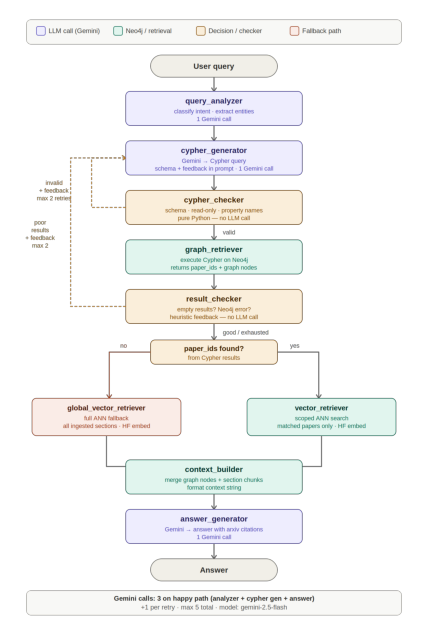

In [43]:
from pathlib import Path
import matplotlib.pyplot as plt

image_path = Path("../papergraph_agent_flow.png")

img = plt.imread(image_path)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
import os
import re
import time
import json
import numpy as np
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv

from neo4j import GraphDatabase
from huggingface_hub import InferenceClient
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

In [7]:
NEO4J_URI      = os.getenv("NEO4J_URI")
NEO4J_AUTH     = (os.getenv("NEO4J_USERNAME"), os.getenv("NEO4J_PASSWORD"))
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE")
HF_TOKEN       = os.getenv("HF_TOKEN")
HF_EMBED_MODEL = "BAAI/bge-base-en-v1.5"

driver    = GraphDatabase.driver(NEO4J_URI, auth=NEO4J_AUTH)
hf_client = InferenceClient(token=HF_TOKEN)

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

MAX_RETRIES    = 2
TOP_K_SECTIONS = 5

In [8]:
SCHEMA_CONTEXT = """
Neo4j Graph Schema:

NODE LABELS & KEY PROPERTIES:
  Paper    : arxiv_id, title, title_norm, abstract, summary, year, category, stub (bool)
  Author   : author_id, name, name_norm
  Section  : section_id, title, content, section_order, embedding (list[float], 768-dim)
  Concept  : concept_id, name, name_norm, description
  Method   : method_id, name, name_norm, description
  Dataset  : dataset_id, name, name_norm, description
  Topic    : topic_id, name, name_norm, description

RELATIONSHIPS:
  (Paper)-[:AUTHORED_BY]->(Author)
  (Author)-[:CO_AUTHORED]-(Author)          -- has paper_count property
  (Paper)-[:HAS_SECTION]->(Section)
  (Section)-[:NEXT_SECTION]->(Section)
  (Paper)-[:INTRODUCES]->(Concept)          -- has confidence, source
  (Paper)-[:APPLIES]->(Concept)             -- has confidence, source
  (Paper)-[:USES_METHOD]->(Method)          -- has confidence, source
  (Paper)-[:USES_DATASET]->(Dataset)        -- has confidence, source
  (Paper)-[:BELONGS_TO]->(Topic)            -- has confidence, source
  (Topic)-[:BELONGS_TO]->(Topic)            -- topic hierarchy
  (Concept)-[:RELATED_TO]->(Concept)        -- has confidence, source
  (Method)-[:EXTENDS]->(Method)             -- has confidence, source
  (Paper)-[:EXTENDS]->(Paper)               -- has source
  (Paper)-[:CONTRADICTS]->(Paper)           -- has source
  (Paper)-[:CITES]->(Paper)                 -- bibliography citations

IMPORTANT RULES FOR CYPHER:
  - Always use name_norm for matching Concept/Method/Dataset/Topic (lowercase normalized)
  - Use toLower(trim(...)) when matching user-provided strings
  - stub=false papers are fully ingested; stub=true are citation placeholders
  - Return paper arxiv_id always so we can scope vector search
  - Limit results (LIMIT 10 for papers, LIMIT 20 for entities)
  - Return only: arxiv_id, title, year, and relevant entity names
"""

In [9]:
class AgentState(TypedDict):
    # core
    query: str
    messages: Annotated[list, lambda x, y: x + y]  # MemorySaver accumulates

    # analysis
    intent: str           # conceptual | comparative | lineage | factual
    entities: list[str]   # key terms extracted from query

    # cypher loop
    cypher: str
    cypher_feedback: str
    cypher_retries: int
    cypher_valid: bool

    # graph results
    graph_nodes: list[dict]
    paper_ids: list[str]

    # result loop
    result_feedback: str
    result_retries: int
    result_ok: bool

    # retrieval
    sections: list[dict]

    # final
    context: str
    answer: str

In [10]:
def _embed(text: str) -> list[float]:
    arr = np.array(hf_client.feature_extraction(text, model=HF_EMBED_MODEL))
    if arr.ndim == 3:
        arr = arr[0]
    if arr.ndim == 2:
        arr = arr.mean(axis=0)
    return arr.tolist()


def _run_cypher(cypher: str) -> tuple[list[dict], str | None]:
    """Returns (records, error_message). error_message is None on success."""
    try:
        results, _, _ = driver.execute_query(cypher, database_=NEO4J_DATABASE)
        return [dict(r) for r in results], None
    except Exception as e:
        return [], str(e)


def _run_cypher_raw(cypher: str, **params) -> tuple[list[dict], str | None]:
    """Like _run_cypher but accepts extra keyword params for parameterised queries."""
    try:
        results, _, _ = driver.execute_query(cypher, database_=NEO4J_DATABASE, **params)
        return [dict(r) for r in results], None
    except Exception as e:
        return [], str(e)


def _llm_call_with_retry(messages: list, retries: int = 3, wait: int = 60):
    """Wraps llm.invoke with automatic back-off on 429 quota errors."""
    for attempt in range(retries):
        try:
            return llm.invoke(messages)
        except Exception as e:
            if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
                if attempt < retries - 1:
                    print(f"[429] Quota hit, waiting {wait}s... (attempt {attempt+1}/{retries})")
                    time.sleep(wait)
                else:
                    raise
            else:
                raise


def _llm_json(prompt: str) -> dict:
    """Call LLM, strip markdown fences, parse JSON."""
    response = _llm_call_with_retry([HumanMessage(content=prompt)])
    text = response.content.strip()
    text = re.sub(r"^```(?:json)?\n?", "", text)
    text = re.sub(r"\n?```$", "", text)
    return json.loads(text)

In [11]:
def query_analyzer(state: AgentState) -> dict:
    prompt = f"""Analyze this research query and return JSON only.

Query: \"{state['query']}\"

Return this exact JSON structure:
{{
  "intent": "<one of: conceptual | comparative | lineage | factual>",
  "entities": ["<key term 1>", "<key term 2>", ...]
}}

Intent definitions:
- conceptual  : asking what something is or how it works ("what is LoRA?")
- comparative : comparing papers, methods, or concepts ("LoRA vs full fine-tuning")
- lineage     : asking about citations, extensions, contradictions ("what builds on BERT?")
- factual     : specific fact lookup ("who authored attention is all you need?")

Entities: extract specific method names, concept names, dataset names, author names, or topic names.
Return maximum 5 entities. Normalize to lowercase."""

    result = _llm_json(prompt)
    return {
        "intent":          result.get("intent", "conceptual"),
        "entities":        result.get("entities", []),
        "cypher_retries":  0,
        "result_retries":  0,
        "cypher_feedback": "",
        "result_feedback": "",
        "messages":        [HumanMessage(content=state["query"])],
    }

In [ ]:
def cypher_generator(state: AgentState) -> dict:
    feedback_block = ""
    if state.get("cypher_feedback"):
        feedback_block = (
            f"PREVIOUS ATTEMPT FAILED — fix it:\n"
            f"Cypher tried: {state.get('cypher', '')}\n"
            f"Feedback: {state['cypher_feedback']}\n"
        )

    prompt = f"""{SCHEMA_CONTEXT}

{feedback_block}
Generate a Cypher READ query for this research question.

Query: \"{state['query']}\"
Intent: {state['intent']}
Extracted entities: {state['entities']}

Rules:
- READ only (MATCH/RETURN, no MERGE/CREATE/DELETE)
- Always return p.arxiv_id AS arxiv_id for any Paper node
- Use LIMIT to cap results
- Return clean column names (no nested maps)
- Output ONLY the raw Cypher, no explanation, no markdown fences"""

    response = _llm_call_with_retry([HumanMessage(content=prompt)])
    cypher = response.content.strip().strip("```").strip()
    if cypher.lower().startswith("cypher"):
        cypher = cypher[6:].strip()

    return {"cypher": cypher}

In [13]:
VALID_LABELS = {"Paper", "Author", "Section", "Concept", "Method", "Dataset", "Topic"}
VALID_RELS   = {
    "AUTHORED_BY", "CO_AUTHORED", "HAS_SECTION", "NEXT_SECTION",
    "INTRODUCES", "APPLIES", "USES_METHOD", "USES_DATASET",
    "BELONGS_TO", "RELATED_TO", "EXTENDS", "CONTRADICTS", "CITES",
}


def cypher_checker(state: AgentState) -> dict:
    """Pure Python schema validation — no LLM call needed."""
    cypher = state.get("cypher", "")
    issues = []

    # 1. Must be read-only
    write_kw = re.findall(r"\b(MERGE|CREATE|DELETE|SET|REMOVE|DROP)\b", cypher, re.IGNORECASE)
    if write_kw:
        issues.append(f"Write operations not allowed: {write_kw}")

    # 2. Node labels must be valid
    used_labels = set(re.findall(r"\([\w]*:(\w+)", cypher))
    bad_labels = used_labels - VALID_LABELS
    if bad_labels:
        issues.append(f"Unknown node labels: {bad_labels}. Valid: {VALID_LABELS}")

    # 3. Relationship types must be valid
    used_rels = set(re.findall(r"\[:(\w+)\]", cypher))
    bad_rels = used_rels - VALID_RELS
    if bad_rels:
        issues.append(f"Unknown relationship types: {bad_rels}. Valid: {VALID_RELS}")

    # 4. Must have RETURN
    if "RETURN" not in cypher.upper():
        issues.append("Query must have a RETURN clause.")

    # 5. Common wrong property names
    bad_props = {
        "p.title_lower": "use p.title_norm",
        "c.name":        "use c.name_norm for matching",
        "m.name":        "use m.name_norm for matching",
        "t.name":        "use t.name_norm for matching",
        "a.name":        "use a.name_norm for matching authors",
    }
    for bad, fix in bad_props.items():
        if bad in cypher:
            issues.append(f"Property hint: '{bad}' — {fix}")

    if issues:
        feedback = "Cypher issues found:\n" + "\n".join(f"  - {i}" for i in issues)
        return {
            "cypher_valid":    False,
            "cypher_feedback": feedback,
            "cypher_retries":  state.get("cypher_retries", 0) + 1,
        }

    return {"cypher_valid": True, "cypher_feedback": ""}

In [14]:
def graph_retriever(state: AgentState) -> dict:
    records, error = _run_cypher(state["cypher"])

    if error:
        return {
            "graph_nodes":     [],
            "paper_ids":       [],
            "result_ok":       False,
            "result_feedback": f"Neo4j execution error: {error}",
            "result_retries":  state.get("result_retries", 0) + 1,
        }

    paper_ids = list({
        r["arxiv_id"] for r in records
        if r.get("arxiv_id") and isinstance(r["arxiv_id"], str)
    })

    return {
        "graph_nodes": records,
        "paper_ids":   paper_ids,
    }

In [ ]:
def result_checker(state: AgentState) -> dict:
    """
    Checks graph retrieval quality without an LLM call.
    """
    nodes   = state.get("graph_nodes", [])
    retries = state.get("result_retries", 0)

    # Neo4j execution error passed up from graph_retriever
    if state.get("result_feedback", "").startswith("Neo4j execution error"):
        if retries >= MAX_RETRIES:
            return {"result_ok": True, "paper_ids": []}  # fall to global vector
        return {
            "result_ok":       False,
            "cypher_feedback": state["result_feedback"],
            "cypher_retries":  state.get("cypher_retries", 0) + 1,
        }

    # Empty results — deterministic feedback, no LLM
    if not nodes:
        if retries >= MAX_RETRIES:
            return {"result_ok": True, "paper_ids": []}  # fall to global vector

        feedback = (
            "Query returned 0 results. Try: "
            "1) remove strict WHERE filters, "
            "2) use CONTAINS instead of exact match, "
            "3) broaden to related node types."
        )
        return {
            "result_ok":       False,
            "result_feedback": feedback,
            "cypher_feedback": feedback,
            "result_retries":  retries + 1,
            "cypher_retries":  state.get("cypher_retries", 0) + 1,
        }

    return {"result_ok": True, "result_feedback": ""}

In [16]:
def vector_retriever(state: AgentState) -> dict:
    """Scoped ANN — only searches sections belonging to graph-matched papers."""
    query_vec = _embed(state["query"])
    cypher = """
    CALL db.index.vector.queryNodes('section_embedding', $k, $qvec)
    YIELD node AS s, score
    MATCH (p:Paper)-[:HAS_SECTION]->(s)
    WHERE p.arxiv_id IN $paper_ids
    RETURN s.section_id AS section_id,
           s.title      AS section_title,
           s.content    AS content,
           p.arxiv_id   AS arxiv_id,
           p.title      AS paper_title,
           score
    """
    # Over-fetch then trim to guarantee TOP_K within the scoped paper set
    records, _ = _run_cypher_raw(
        cypher,
        paper_ids=state["paper_ids"],
        qvec=query_vec,
        k=TOP_K_SECTIONS * 4,
    )
    return {"sections": records[:TOP_K_SECTIONS]}

In [17]:
def global_vector_retriever(state: AgentState) -> dict:
    """Fallback ANN — searches all fully-ingested sections."""
    query_vec = _embed(state["query"])
    cypher = """
    CALL db.index.vector.queryNodes('section_embedding', $k, $qvec)
    YIELD node AS s, score
    MATCH (p:Paper)-[:HAS_SECTION]->(s)
    WHERE p.stub = false
    RETURN s.section_id AS section_id,
           s.title      AS section_title,
           s.content    AS content,
           p.arxiv_id   AS arxiv_id,
           p.title      AS paper_title,
           score
    """
    records, _ = _run_cypher_raw(cypher, qvec=query_vec, k=TOP_K_SECTIONS)
    return {"sections": records}

In [18]:
def context_builder(state: AgentState) -> dict:
    parts = []

    if state.get("graph_nodes"):
        parts.append("=== Graph Context ===")
        seen = set()
        for node in state["graph_nodes"][:15]:
            line = " | ".join(f"{k}: {v}" for k, v in node.items() if v is not None)
            if line not in seen:
                seen.add(line)
                parts.append(f"  {line}")

    if state.get("sections"):
        parts.append("\n=== Relevant Paper Sections ===")
        for sec in state["sections"]:
            parts.append(
                f"\n[{sec.get('paper_title', 'Unknown')} | {sec.get('arxiv_id', '')}]"
                f" — {sec.get('section_title', '')}\n"
                f"{sec.get('content', '')[:800]}"
            )

    context = "\n".join(parts) if parts else "No relevant context found in the knowledge graph."
    return {"context": context}

In [19]:
def answer_generator(state: AgentState) -> dict:
    system = """You are a research assistant with access to a knowledge graph of academic papers.
Answer the user's question using only the provided context.
- Cite papers using their arxiv_id in brackets e.g. [2203.08975]
- Be concise but complete
- If context is insufficient, say so clearly
- Do not hallucinate paper titles or results"""

    user_prompt = f"""Question: {state['query']}

Context:
{state['context']}

Answer:"""

    response = _llm_call_with_retry([
        SystemMessage(content=system),
        HumanMessage(content=user_prompt),
    ])
    answer = response.content.strip()

    return {
        "answer":   answer,
        "messages": [AIMessage(content=answer)],
    }

In [20]:
def route_cypher_checker(
    state: AgentState,
) -> Literal["cypher_generator", "graph_retriever"]:
    if not state.get("cypher_valid", False):
        if state.get("cypher_retries", 0) >= MAX_RETRIES:
            return "graph_retriever"  # force through, let Neo4j catch it
        return "cypher_generator"
    return "graph_retriever"


def route_result_checker(
    state: AgentState,
) -> Literal["cypher_generator", "vector_retriever", "global_vector_retriever"]:
    if not state.get("result_ok", False):
        if state.get("result_retries", 0) < MAX_RETRIES:
            return "cypher_generator"

    if state.get("paper_ids"):
        return "vector_retriever"
    return "global_vector_retriever"

In [21]:
def build_agent():
    g = StateGraph(AgentState)

    g.add_node("query_analyzer",          query_analyzer)
    g.add_node("cypher_generator",        cypher_generator)
    g.add_node("cypher_checker",          cypher_checker)
    g.add_node("graph_retriever",         graph_retriever)
    g.add_node("result_checker",          result_checker)
    g.add_node("vector_retriever",        vector_retriever)
    g.add_node("global_vector_retriever", global_vector_retriever)
    g.add_node("context_builder",         context_builder)
    g.add_node("answer_generator",        answer_generator)

    g.set_entry_point("query_analyzer")

    g.add_edge("query_analyzer",   "cypher_generator")
    g.add_edge("cypher_generator", "cypher_checker")

    g.add_conditional_edges(
        "cypher_checker",
        route_cypher_checker,
        {"cypher_generator": "cypher_generator", "graph_retriever": "graph_retriever"},
    )

    g.add_edge("graph_retriever", "result_checker")

    g.add_conditional_edges(
        "result_checker",
        route_result_checker,
        {
            "cypher_generator":        "cypher_generator",
            "vector_retriever":        "vector_retriever",
            "global_vector_retriever": "global_vector_retriever",
        },
    )

    g.add_edge("vector_retriever",        "context_builder")
    g.add_edge("global_vector_retriever", "context_builder")
    g.add_edge("context_builder",         "answer_generator")
    g.add_edge("answer_generator",        END)

    memory = MemorySaver()
    return g.compile(checkpointer=memory)

In [22]:
agent = build_agent()
print("Agent compiled successfully.")

Agent compiled successfully.


In [23]:
def ask(query: str, thread_id: str = "default") -> str:
    """
    Run a query through the agent.
    thread_id keeps conversation history separate per user/session.
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke(
        {"query": query, "messages": []},
        config=config,
    )
    return result["answer"]


def ask_stream(query: str, thread_id: str = "default"):
    """Stream node-by-node updates — useful for debugging or UI progress."""
    config = {"configurable": {"thread_id": thread_id}}
    for event in agent.stream(
        {"query": query, "messages": []},
        config=config,
        stream_mode="updates",
    ):
        node_name = list(event.keys())[0]
        node_out  = event[node_name]
        yield node_name, node_out

In [25]:
answer = ask(
    query="Who are all the authors",
    thread_id="user_001",
)
print(answer)

The authors are:
* Changxi Zhu
* Daniel Dupont
* Gildas Morvan
* Jean-Baptiste Soyez
* Mehdi Dastani
* Rochdi Merzouki
* Shihan Wang
